<a href="https://colab.research.google.com/github/anthony-yt/5g-rural-coverage-heuristics/blob/yosue_tarea_1/heuristics/outputs/analisis_comparativo_resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Comparativo de Resultados: Algoritmo Genético vs Recocido Simulado
**Proyecto:** Optimización de Cobertura 5G en Zonas Rurales

Este cuaderno procesa los historiales de convergencia y el vector final de potencias generados por los algoritmos heurísticos.
El objetivo es visualizar el estado final de la grilla (mapa 3D) y comparar el rendimiento de ambos métodos.



# **Celda 1: Instalación de Paquetes**

In [8]:
import Pkg
Pkg.add(["CSV", "DataFrames", "Plots", "PlotlyBase"])
using CSV, DataFrames, Plots

# Activar el motor interactivo 3D
plotly()

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Plots.PlotlyBackend()

# **Celda 2: Generación de Datos de Prueba**

In [9]:
# Crear la carpeta de salida
mkpath("analytics/output")

# Simular 100 antenas
ids = 1:100
pos_x = repeat(0.5:1.0:9.5, inner=10)
pos_y = repeat(0.5:1.0:9.5, outer=10)
potencias = [i % 3 == 0 ? 0.0 : rand() * 0.5 + 0.5 for i in 1:100]

df_dummy = DataFrame(ID_Antena=ids, Pos_X=pos_x, Pos_Y=pos_y, Potencia_W=potencias)
CSV.write("analytics/output/potencias_por_lambda.csv", df_dummy)

println("Datos de prueba creados en analytics/output/potencias_por_lambda.csv")

Datos de prueba creados en analytics/output/potencias_por_lambda.csv


# **Celda 3: (El Mapa 3D)**

In [10]:
ruta_csv = "analytics/output/potencias_por_lambda.csv"
ruta_salida_mapa = "analytics/output/coverage_map_3d.html"

df = CSV.read(ruta_csv, DataFrame)
activas = filter(row -> row.Potencia_W > 0.1, df)
apagadas = filter(row -> row.Potencia_W <= 0.1, df)

mapa_3d = scatter3d(
    title = "Mapa 3D - Estado de Antenas (GA vs SA)",
    xlabel = "Posición X (km)",
    ylabel = "Posición Y (km)",
    zlabel = "Potencia (W)",
    legend = :topright,
    camera = (45, 30)
)

scatter3d!(mapa_3d, apagadas.Pos_X, apagadas.Pos_Y, apagadas.Potencia_W,
           color = :gray, markersize = 3, label = "Apagadas")

scatter3d!(mapa_3d, activas.Pos_X, activas.Pos_Y, activas.Potencia_W,
           color = :red, markersize = 5, label = "Activas (>0.1W)")

savefig(mapa_3d, ruta_salida_mapa)
display(mapa_3d)

println("Mapa 3D guardado exitosamente en: ", ruta_salida_mapa)

Mapa 3D guardado exitosamente en: analytics/output/coverage_map_3d.html


# **Celda 4: (Gráfico de Convergencia)**

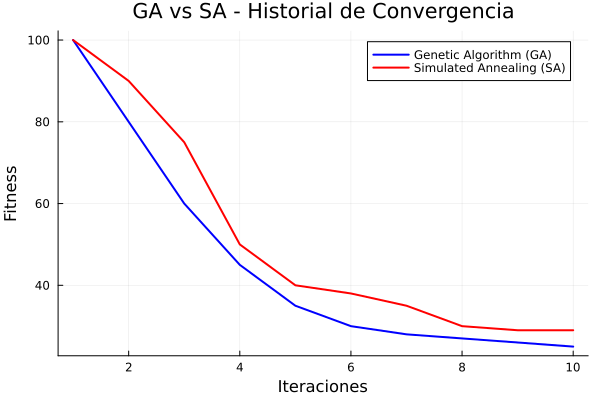

Gráfico de convergencia guardado en: analytics/output/convergence_plots.png


In [11]:
# Activamos el motor básico de Julia para exportar el PNG
gr()

ruta_salida_grafico = "analytics/output/convergence_plots.png"

# Reemplazar estos arrays cuando Gael y Manuel entreguen sus historiales
historial_GA = [100, 80, 60, 45, 35, 30, 28, 27, 26, 25]
historial_SA = [100, 90, 75, 50, 40, 38, 35, 30, 29, 29]

grafico_convergencia = plot(historial_GA, label="Genetic Algorithm (GA)", color=:blue, linewidth=2)
plot!(grafico_convergencia, historial_SA, label="Simulated Annealing (SA)", color=:red, linewidth=2,
      title="GA vs SA - Historial de Convergencia", xlabel="Iteraciones", ylabel="Fitness")

savefig(grafico_convergencia, ruta_salida_grafico)
display(grafico_convergencia)

println("Gráfico de convergencia guardado en: ", ruta_salida_grafico)